# DirectLiNGAM: `lingam` vs `ruslingam` Execution Time Comparison

Compares the `fit()` execution time of `lingam.DirectLiNGAM` and `ruslingam.DirectLiNGAM`
(both using the default `adaptive_lasso=True`) across a grid of feature counts and
sample counts.

- Feature counts: 5, 10, 20, 50, 100
- Sample counts: 1,000 / 2,000 / 5,000 / 10,000
- For each (features, samples) combination, runs are repeated with 5 different random
  seeds, and the mean and standard deviation of the execution time are aggregated.
- Data generation reuses `make_sem` (a lower-triangular linear SEM with non-Gaussian
  noise) and `fmt` (time formatting) from `benchmarks/bench_direct_lingam.py` as-is.

**Note:** around `features=100` with `samples>=5000`, a single `fit()` call on the
`lingam` side takes about a minute, so running this notebook end-to-end takes
roughly 30 minutes in total.

## Execution Environment

In [1]:
import importlib.metadata
import os
import platform
import sys

import numpy as np
import lingam
import ruslingam

print("execution environment")
print("-" * 40)
print(f"platform     : {platform.platform()}")
print(f"processor    : {platform.processor() or platform.machine()}")
print(f"logical CPUs : {os.cpu_count()}")
print(f"python       : {sys.version.split()[0]}")
print(f"numpy        : {np.__version__}")
print(f"lingam       : {lingam.__version__}")
print(f"ruslingam    : {importlib.metadata.version('ruslingam')}")

execution environment
----------------------------------------
platform     : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
processor    : x86_64
logical CPUs : 24
python       : 3.12.3
numpy        : 2.2.6
lingam       : 1.13.0
ruslingam    : 0.1.0


## Setup

In [2]:
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BENCH_DIR = Path.cwd()
if str(BENCH_DIR) not in sys.path:
    sys.path.insert(0, str(BENCH_DIR))

# Reuse the bench_direct_lingam.py helpers (avoid duplicating the implementation)
from bench_direct_lingam import make_sem, fmt

In [3]:
FEATURE_SIZES = [5, 10, 20, 50, 100]
SAMPLE_SIZES = [1000, 2000, 5000, 10000]
SEEDS = range(5)
ADAPTIVE_LASSO = True

print(f"features       = {FEATURE_SIZES}")
print(f"samples        = {SAMPLE_SIZES}")
print(f"seeds          = {list(SEEDS)}")
print(f"adaptive_lasso = {ADAPTIVE_LASSO}")
print(
    f"total configs  = {len(FEATURE_SIZES) * len(SAMPLE_SIZES)} "
    f"(x {len(list(SEEDS))} seeds x 2 libraries = "
    f"{len(FEATURE_SIZES) * len(SAMPLE_SIZES) * len(list(SEEDS)) * 2} fit() calls)"
)

features       = [5, 10, 20, 50, 100]
samples        = [1000, 2000, 5000, 10000]
seeds          = [0, 1, 2, 3, 4]
adaptive_lasso = True
total configs  = 20 (x 5 seeds x 2 libraries = 200 fit() calls)


## Running the Benchmark (~30 minutes)

For each `(features, samples)` combination, generates data from `make_sem` for each of
5 seeds, fits both implementations once each, and measures the elapsed time. Also
records whether `causal_order_` matches between the two implementations (no extra
`fit()` calls are needed for this).

In [4]:
records = []
header = (
    f"{'features':>8} {'samples':>8} {'seed':>4} | "
    f"{'lingam':>12} {'ruslingam':>12} | {'speedup':>8}  {'order match':>11}"
)
print(header)
print("-" * len(header))

t_start = time.perf_counter()
for p in FEATURE_SIZES:
    for n in SAMPLE_SIZES:
        for seed in SEEDS:
            X = make_sem(seed, n, p)

            t0 = time.perf_counter()
            ref_model = lingam.DirectLiNGAM(adaptive_lasso=ADAPTIVE_LASSO).fit(X)
            ref_time = time.perf_counter() - t0

            t0 = time.perf_counter()
            rus_model = ruslingam.DirectLiNGAM(adaptive_lasso=ADAPTIVE_LASSO).fit(X)
            rus_time = time.perf_counter() - t0

            match = list(map(int, ref_model.causal_order_)) == list(map(int, rus_model.causal_order_))
            speedup = ref_time / rus_time if rus_time else float("inf")

            print(
                f"{p:>8} {n:>8} {seed:>4} | "
                f"{fmt(ref_time):>12} {fmt(rus_time):>12} | "
                f"{speedup:>7.1f}x  {('yes' if match else 'NO'):>11}"
            )

            records.append(
                {
                    "features": p,
                    "samples": n,
                    "seed": seed,
                    "lingam_time": ref_time,
                    "ruslingam_time": rus_time,
                    "causal_order_match": match,
                }
            )

elapsed = time.perf_counter() - t_start
print("-" * len(header))
print(f"total elapsed: {elapsed / 60:.1f} min")

raw_df = pd.DataFrame(records)
raw_df.head()

features  samples seed |       lingam    ruslingam |  speedup  order match
--------------------------------------------------------------------------
       5     1000    0 |     14.11 ms      1.27 ms |    11.1x          yes
       5     1000    1 |     10.54 ms      1.15 ms |     9.2x          yes
       5     1000    2 |     11.32 ms      1.12 ms |    10.1x          yes
       5     1000    3 |     11.31 ms      1.14 ms |     9.9x          yes
       5     1000    4 |     11.10 ms      1.13 ms |     9.8x          yes
       5     2000    0 |     12.00 ms      2.20 ms |     5.4x          yes
       5     2000    1 |     12.07 ms      2.22 ms |     5.4x          yes
       5     2000    2 |     11.97 ms      2.20 ms |     5.5x          yes
       5     2000    3 |     11.56 ms      2.18 ms |     5.3x          yes
       5     2000    4 |     11.44 ms      2.14 ms |     5.3x          yes
       5     5000    0 |     16.39 ms      5.42 ms |     3.0x          yes
       5     5000    1 | 

       5     5000    2 |     16.57 ms      5.25 ms |     3.2x          yes
       5     5000    3 |     15.19 ms      5.38 ms |     2.8x          yes
       5     5000    4 |     14.85 ms      5.36 ms |     2.8x          yes
       5    10000    0 |     21.93 ms     10.95 ms |     2.0x          yes
       5    10000    1 |     20.80 ms     10.77 ms |     1.9x          yes
       5    10000    2 |     21.35 ms     10.76 ms |     2.0x          yes
       5    10000    3 |     20.62 ms     10.86 ms |     1.9x          yes


       5    10000    4 |     21.01 ms     10.39 ms |     2.0x          yes
      10     1000    0 |     54.90 ms     16.45 ms |     3.3x          yes
      10     1000    1 |     54.88 ms     13.81 ms |     4.0x          yes


      10     1000    2 |     54.59 ms     14.18 ms |     3.8x          yes
      10     1000    3 |     53.90 ms     14.49 ms |     3.7x          yes
      10     1000    4 |     53.08 ms     14.12 ms |     3.8x          yes


      10     2000    0 |     66.32 ms     17.72 ms |     3.7x          yes
      10     2000    1 |     64.66 ms     18.61 ms |     3.5x          yes
      10     2000    2 |     76.03 ms     20.05 ms |     3.8x          yes


...

     100    10000    1 |   120.425 s     10.560 s  |    11.4x          yes


     100    10000    2 |   118.536 s      9.607 s  |    12.3x          yes


     100    10000    3 |   120.069 s     10.204 s  |    11.8x          yes


     100    10000    4 |   117.636 s      9.810 s  |    12.0x          yes
--------------------------------------------------------------------------
total elapsed: 29.1 min


,features,samples,seed,lingam_time,ruslingam_time,causal_order_match
0,5,1000,0,0.014106,0.001266,True
1,5,1000,1,0.010540,0.001148,True
2,5,1000,2,0.011324,0.001121,True
3,5,1000,3,0.011315,0.001137,True
4,5,1000,4,0.011099,0.001129,True


## Aggregation

In [5]:
summary = (
    raw_df.groupby(["features", "samples"])
    .agg(
        lingam_mean=("lingam_time", "mean"),
        lingam_std=("lingam_time", "std"),
        ruslingam_mean=("ruslingam_time", "mean"),
        ruslingam_std=("ruslingam_time", "std"),
        order_match_rate=("causal_order_match", "mean"),
    )
    .reset_index()
)
summary["speedup"] = summary["lingam_mean"] / summary["ruslingam_mean"]
summary

,features,samples,lingam_mean,lingam_std,ruslingam_mean,ruslingam_std,order_match_rate,speedup
0,5,1000,0.011677,0.001395,0.001160,0.000060,1.0,10.064470
1,5,2000,0.011808,0.000287,0.002190,0.000029,1.0,5.392218
2,5,5000,0.015694,0.000753,0.005358,0.000065,1.0,2.928783
3,5,10000,0.021145,0.000517,0.010748,0.000212,1.0,1.967234
4,10,1000,0.054272,0.000778,0.014612,0.001055,1.0,3.714235
5,10,2000,0.068991,0.005687,0.018928,0.000856,1.0,3.644832
6,10,5000,0.091907,0.003440,0.028073,0.001248,1.0,3.273904
7,10,10000,0.133200,0.002380,0.046685,0.000623,1.0,2.853199
8,20,1000,0.364119,0.010046,0.089845,0.007220,1.0,4.052743
9,20,2000,0.420387,0.009737,0.103434,0.015613,1.0,4.064293


## Charts

For each feature count, plots a chart with samples on the x-axis and `fit()` execution
time (seconds, log scale) on the y-axis. Error bars show the standard deviation across
the 5 seeds.

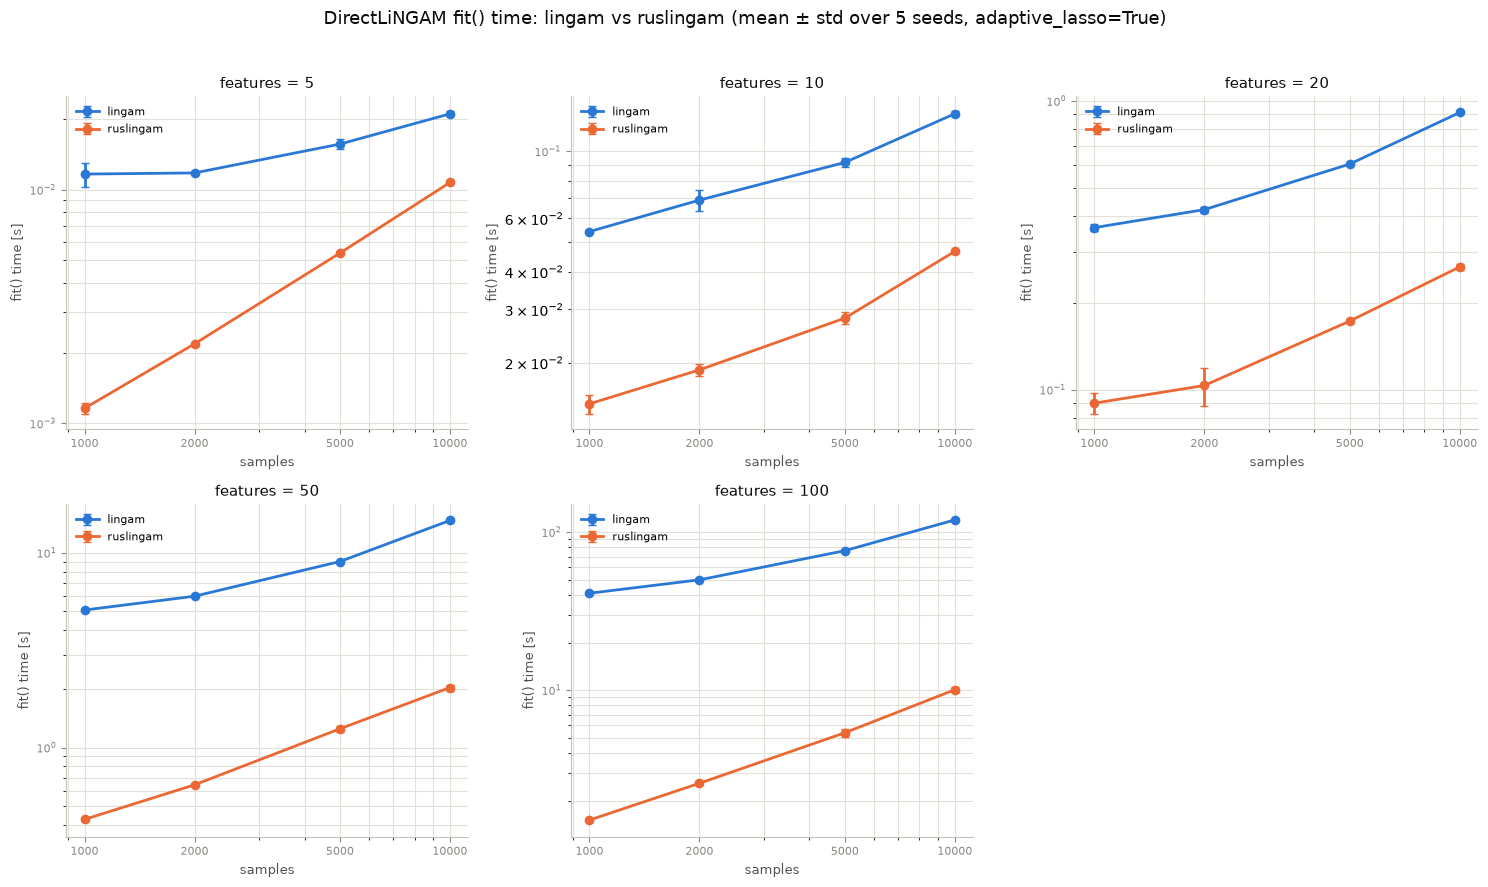

In [6]:
# dataviz skill's categorical palette (fixed order, never cycled): slot1=blue, slot2=orange
COLOR_LINGAM = "#2a78d6"
COLOR_RUSLINGAM = "#eb6834"
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#c3c2b7"
TEXT_MUTED = "#898781"
TEXT_SECONDARY = "#52514e"
TEXT_PRIMARY = "#0b0b0b"

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, p in zip(axes, FEATURE_SIZES):
    sub = summary[summary["features"] == p].sort_values("samples")
    ax.errorbar(
        sub["samples"], sub["lingam_mean"], yerr=sub["lingam_std"],
        marker="o", markersize=6, linewidth=2, color=COLOR_LINGAM, label="lingam",
        capsize=3,
    )
    ax.errorbar(
        sub["samples"], sub["ruslingam_mean"], yerr=sub["ruslingam_std"],
        marker="o", markersize=6, linewidth=2, color=COLOR_RUSLINGAM, label="ruslingam",
        capsize=3,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(SAMPLE_SIZES)
    ax.set_xticklabels([str(s) for s in SAMPLE_SIZES])
    ax.set_title(f"features = {p}", color=TEXT_PRIMARY, fontsize=11)
    ax.set_xlabel("samples", color=TEXT_SECONDARY, fontsize=9)
    ax.set_ylabel("fit() time [s]", color=TEXT_SECONDARY, fontsize=9)
    ax.grid(True, which="both", color=GRID_COLOR, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_COLOR)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.tick_params(colors=TEXT_MUTED, labelsize=8)
    ax.legend(fontsize=8, frameon=False)

for ax in axes[len(FEATURE_SIZES):]:
    ax.axis("off")

fig.suptitle(
    "DirectLiNGAM fit() time: lingam vs ruslingam (mean \u00b1 std over 5 seeds, adaptive_lasso=True)",
    color=TEXT_PRIMARY, fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Table

Shows the same aggregated data as the charts above, in table form.

In [7]:
display_df = summary.copy()
display_df["lingam"] = [f"{m:.3f}s \u00b1 {s:.3f}" for m, s in zip(summary["lingam_mean"], summary["lingam_std"])]
display_df["ruslingam"] = [f"{m:.3f}s \u00b1 {s:.3f}" for m, s in zip(summary["ruslingam_mean"], summary["ruslingam_std"])]
display_df["speedup"] = summary["speedup"].map(lambda x: f"{x:.1f}x")
display_df["order_match_rate"] = summary["order_match_rate"].map(lambda x: f"{x * 100:.0f}%")
display_df = display_df[["features", "samples", "lingam", "ruslingam", "speedup", "order_match_rate"]]
display_df

,features,samples,lingam,ruslingam,speedup,order_match_rate
0,5,1000,0.012s ± 0.001,0.001s ± 0.000,10.1x,100%
1,5,2000,0.012s ± 0.000,0.002s ± 0.000,5.4x,100%
2,5,5000,0.016s ± 0.001,0.005s ± 0.000,2.9x,100%
3,5,10000,0.021s ± 0.001,0.011s ± 0.000,2.0x,100%
4,10,1000,0.054s ± 0.001,0.015s ± 0.001,3.7x,100%
5,10,2000,0.069s ± 0.006,0.019s ± 0.001,3.6x,100%
6,10,5000,0.092s ± 0.003,0.028s ± 0.001,3.3x,100%
7,10,10000,0.133s ± 0.002,0.047s ± 0.001,2.9x,100%
8,20,1000,0.364s ± 0.010,0.090s ± 0.007,4.1x,100%
9,20,2000,0.420s ± 0.010,0.103s ± 0.016,4.1x,100%


## Summary

In [8]:
print(
    f"speedup (mean-of-5): min {summary['speedup'].min():.1f}x   "
    f"median {summary['speedup'].median():.1f}x   max {summary['speedup'].max():.1f}x"
)
if (summary["order_match_rate"] < 1.0).any():
    print("WARNING: causal_order_ disagreed on at least one (features, samples, seed) combination")
else:
    print("causal_order_ matched between lingam and ruslingam on every (features, samples, seed) combination")

speedup (mean-of-5): min 2.0x   median 4.7x   max 27.2x
causal_order_ matched between lingam and ruslingam on every (features, samples, seed) combination
